# Oil & Gas Production Dataset (1967-1999)
## Comprehensive Unsupervised Learning Analysis

In [55]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

plt.style.use("seaborn-v0_8-darkgrid")
PALETTE = "tab10"
np.random.seed(42)

print("=" * 60)
print("  Oil & Gas Unsupervised Learning Analysis")
print("=" * 60)

  Oil & Gas Unsupervised Learning Analysis


## 1. Load Data

In [56]:
df = pd.read_csv("oil-and-gas-summary-production-data-1967-1999-1.csv")
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print("\nMissing values:")
print(df.isna().sum())
df.head()

Loaded dataset: 30,053 rows x 20 columns

Columns: ['Production Year', 'Production Date Entered', 'Operator', 'County', 'Town', 'Field', 'Producing Formation', 'Active Oil Wells', 'Inactive Oil Wells', 'Active Gas Wells', 'Inactive Gas Wells', 'Injection Wells', 'Disposal Wells', 'Self-use Well', 'Oil Produced, bbl', 'Gas Produced, Mcf', 'Water produced, bbl', 'Taxable Gas, Mcf', 'Purchaser Codes', 'Location']

Missing values:
Production Year                0
Production Date Entered        0
Operator                       0
County                        31
Town                         657
Field                       1281
Producing Formation          660
Active Oil Wells               0
Inactive Oil Wells             0
Active Gas Wells               0
Inactive Gas Wells             0
Injection Wells                0
Disposal Wells                 0
Self-use Well                619
Oil Produced, bbl              0
Gas Produced, Mcf              0
Water produced, bbl            0
Taxable 

,Production Year,Production Date Entered,Operator,County,Town,Field,Producing Formation,Active Oil Wells,Inactive Oil Wells,Active Gas Wells,Inactive Gas Wells,Injection Wells,Disposal Wells,Self-use Well,"Oil Produced, bbl","Gas Produced, Mcf","Water produced, bbl","Taxable Gas, Mcf",Purchaser Codes,Location
0,1995,12/3/1996,"Buffalo China, Inc.",Erie,BUFFALO,BUFFALO,MEDINA,0,0,1,0,0,0,YES,0,106,0,0,NaN,"BUFFALO, NY\n(42.887691, -78.879374)"
1,1995,3/29/1996,"Copper Ridge Oil, Inc.",Steuben,WEST UNION,BEECH HILL-INDEPENDENCE,FULMER VALLEY,28,0,0,0,7,0,NO,1229,0,180,0,OA,"WEST UNION, NY\n(42.094951, -77.725816)"
2,1994,2/14/1995,"White, Walter W. & Christina L.",Cattaraugus,CARROLLTON,BRADFORD,BRADFORD,3,0,0,0,0,0,NO,462,0,0,0,OA,"CARROLLTON, NY\n(42.023289, -78.628438)"
3,1994,1/19/1995,"Stiegler, Richard M",Erie,CHEEKTOWAGA,BUFFALO,MEDINA,0,0,1,0,0,0,YES,0,530,0,0,NaN,"CHEEKTOWAGA, NY\n(42.907071, -78.754318)"
4,1995,2/12/1996,"Bucher, Charles J",Cattaraugus,ALLEGANY,FIVE MILE,BRADFORD,10,0,0,0,0,0,NO,45,0,80,0,OA,"ALLEGANY, NY\n(42.088061, -78.491258)"


## 2. Exploratory Data Analysis (EDA)

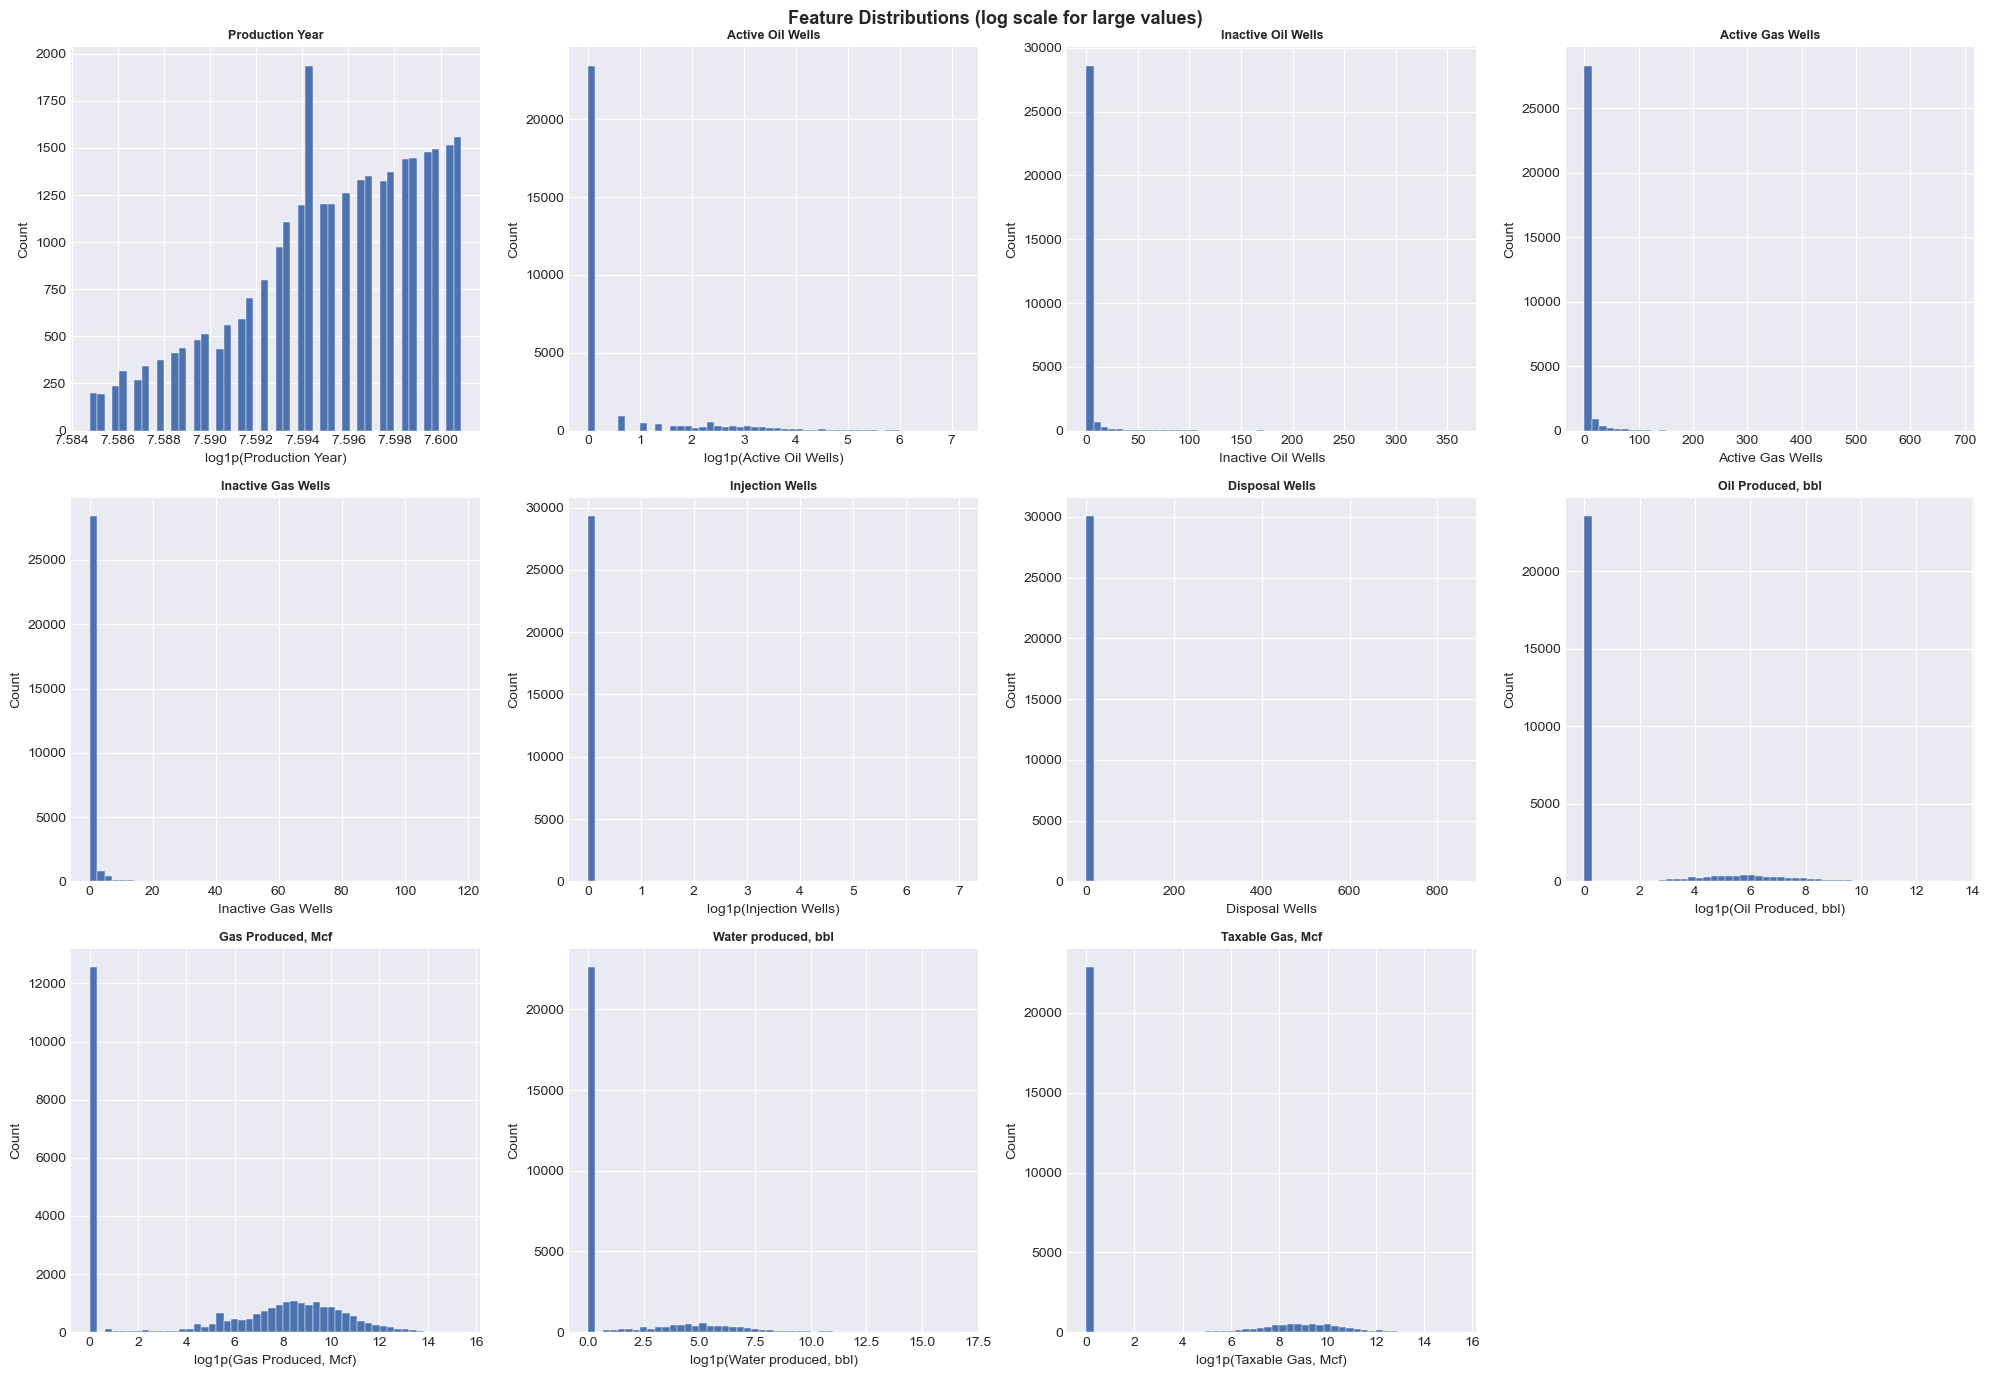

In [57]:
NUM_COLS = [
    "Production Year",
    "Active Oil Wells", "Inactive Oil Wells",
    "Active Gas Wells", "Inactive Gas Wells",
    "Injection Wells", "Disposal Wells",
    "Oil Produced, bbl", "Gas Produced, Mcf",
    "Water produced, bbl", "Taxable Gas, Mcf",
]

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    data = df[col].dropna()
    use_log = data.max() > 1000
    plot_data = np.log1p(data) if use_log else data
    axes[i].hist(plot_data, bins=50, color="#4C72B0", edgecolor="white", linewidth=0.3)
    axes[i].set_xlabel(f"log1p({col})" if use_log else col)
    axes[i].set_title(col, fontsize=9, fontweight="bold")
    axes[i].set_ylabel("Count")
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Feature Distributions (log scale for large values)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

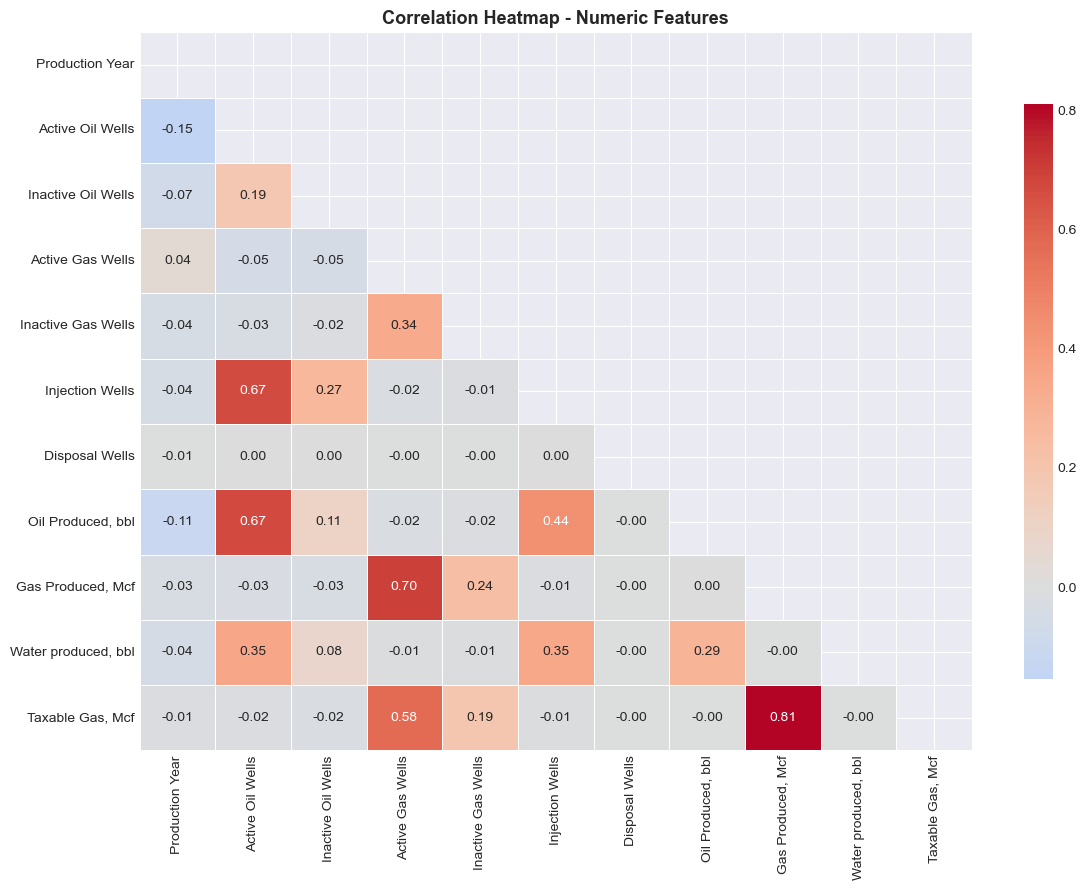

In [58]:
fig, ax = plt.subplots(figsize=(12, 9))
corr = df[NUM_COLS].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap - Numeric Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

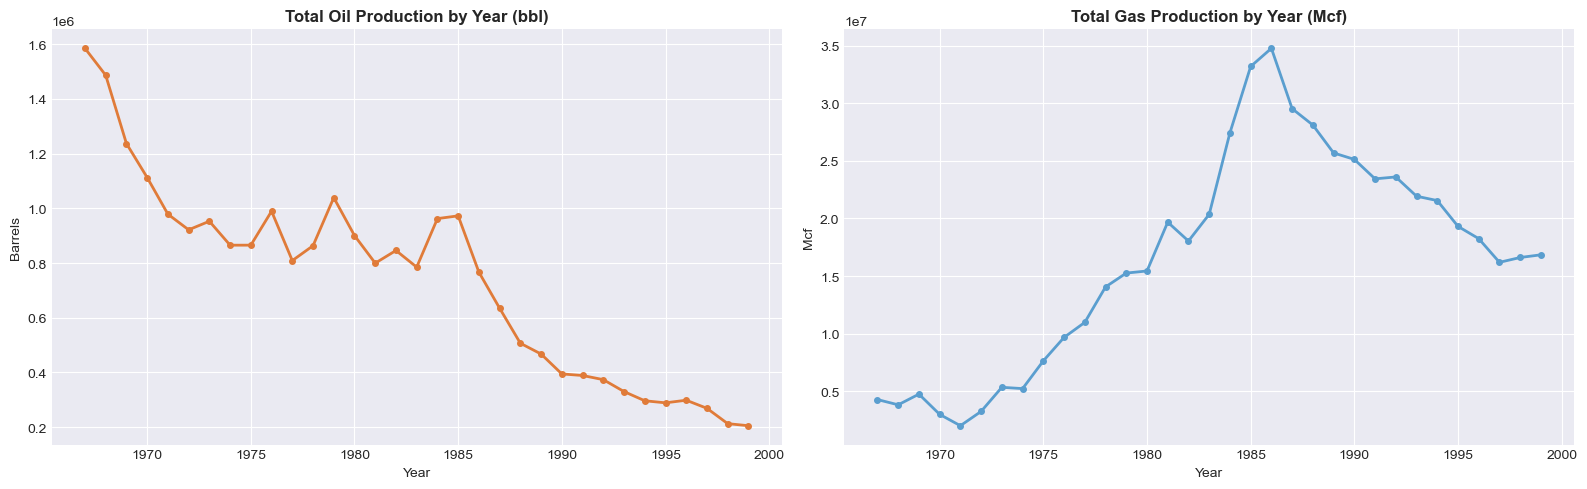

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
yearly = df.groupby("Production Year")[["Oil Produced, bbl", "Gas Produced, Mcf"]].sum()
yearly["Oil Produced, bbl"].plot(ax=axes[0], color="#e07b39", linewidth=2, marker="o", markersize=4)
axes[0].set_title("Total Oil Production by Year (bbl)", fontweight="bold")
axes[0].set_xlabel("Year"); axes[0].set_ylabel("Barrels")
yearly["Gas Produced, Mcf"].plot(ax=axes[1], color="#5a9ecf", linewidth=2, marker="o", markersize=4)
axes[1].set_title("Total Gas Production by Year (Mcf)", fontweight="bold")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Mcf")
plt.tight_layout()
plt.show()

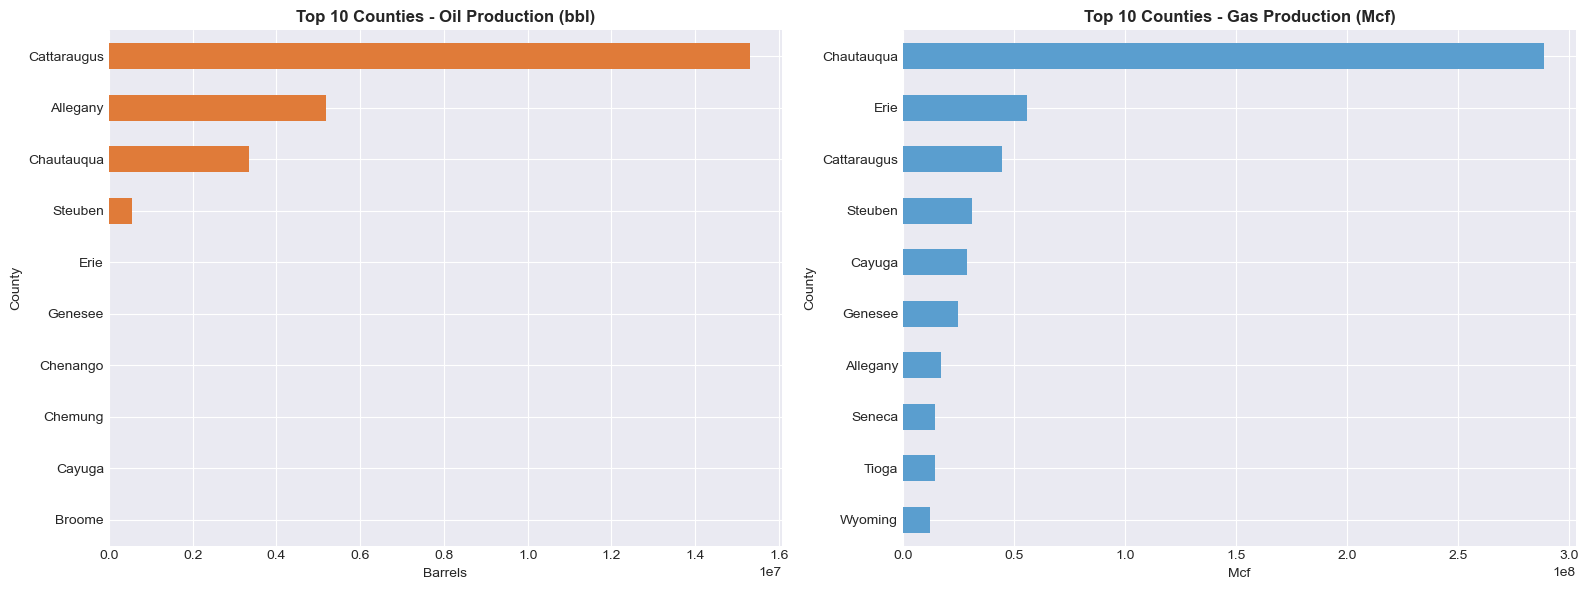

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
top_oil = df.groupby("County")["Oil Produced, bbl"].sum().nlargest(10)
top_gas = df.groupby("County")["Gas Produced, Mcf"].sum().nlargest(10)
top_oil.sort_values().plot(kind="barh", ax=axes[0], color="#e07b39")
axes[0].set_title("Top 10 Counties - Oil Production (bbl)", fontweight="bold")
axes[0].set_xlabel("Barrels")
top_gas.sort_values().plot(kind="barh", ax=axes[1], color="#5a9ecf")
axes[1].set_title("Top 10 Counties - Gas Production (Mcf)", fontweight="bold")
axes[1].set_xlabel("Mcf")
plt.tight_layout()
plt.show()

## 3. Preprocessing & Feature Engineering

In [61]:
df2 = df.copy()

DROP = ["Purchaser Codes", "Production Date Entered", "Operator", "Town", "Field", "Location"]
df2.drop(columns=DROP, inplace=True)

for c in ["County", "Producing Formation", "Self-use Well"]:
    df2[c] = df2[c].fillna("Unknown")

# Feature engineering
df2["Total_Wells"] = (df2["Active Oil Wells"] + df2["Inactive Oil Wells"] +
                       df2["Active Gas Wells"] + df2["Inactive Gas Wells"] +
                       df2["Injection Wells"] + df2["Disposal Wells"])
df2["Is_Gas_Producer"]  = (df2["Gas Produced, Mcf"] > 0).astype(int)
df2["Is_Oil_Producer"]  = (df2["Oil Produced, bbl"] > 0).astype(int)
df2["Production_Total"] = df2["Oil Produced, bbl"] + df2["Gas Produced, Mcf"]
df2["Water_Ratio"] = df2["Water produced, bbl"] / (df2["Production_Total"] + 1)
df2["Oil_per_Well"] = df2["Oil Produced, bbl"] / (df2["Total_Wells"] + 1)
df2["Gas_per_Well"] = df2["Gas Produced, Mcf"] / (df2["Total_Wells"] + 1)

le = LabelEncoder()
for c in ["County", "Producing Formation", "Self-use Well"]:
    df2[c] = le.fit_transform(df2[c].astype(str))

FEATURES = [
    "Production Year",
    "Active Oil Wells", "Inactive Oil Wells",
    "Active Gas Wells", "Inactive Gas Wells",
    "Injection Wells", "Disposal Wells",
    "Oil Produced, bbl", "Gas Produced, Mcf",
    "Water produced, bbl", "Taxable Gas, Mcf",
    "Total_Wells", "Is_Gas_Producer", "Is_Oil_Producer",
    "Production_Total", "Water_Ratio",
    "Oil_per_Well", "Gas_per_Well",
    "County", "Producing Formation", "Self-use Well",
]

X = df2[FEATURES].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Feature matrix: {X_scaled.shape}")
print(f"Features used: {len(FEATURES)}")

Feature matrix: (30053, 21)
Features used: 21


## 4. Dimensionality Reduction (PCA & t-SNE)

PCA explained variance (2 components): 34.9%
Components needed for 85% variance: 12


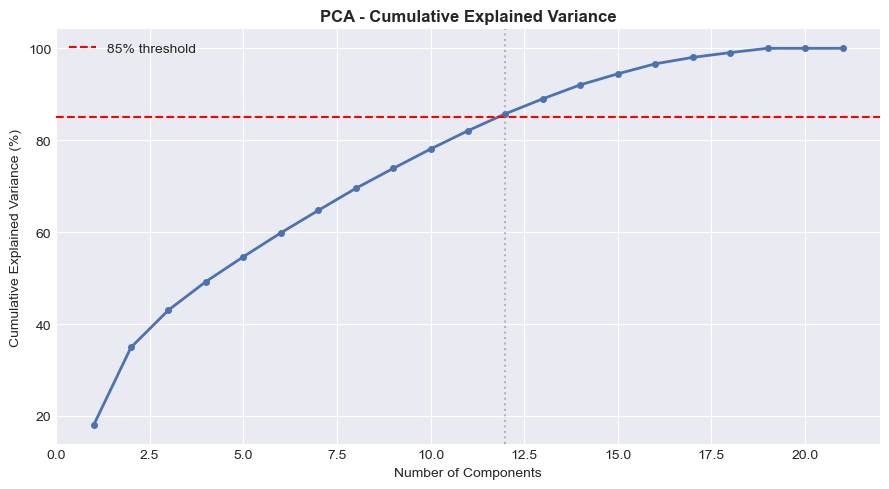

In [62]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum()*100:.1f}%")

pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_) * 100

n_85 = np.argmax(cumvar >= 85) + 1
print(f"Components needed for 85% variance: {n_85}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(cumvar) + 1), cumvar, marker="o", markersize=4, color="#4C72B0", linewidth=2)
ax.axhline(85, color="red", linestyle="--", label="85% threshold")
ax.axvline(n_85, color="gray", linestyle=":", alpha=0.5)
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance (%)")
ax.set_title("PCA - Cumulative Explained Variance", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [63]:
sample_size = min(10000, len(X_scaled))
idx = np.random.choice(len(X_scaled), size=sample_size, replace=False)
print(f"Running t-SNE on {sample_size:,} samples (perplexity=40) ...")
tsne = TSNE(n_components=2, perplexity=40, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_scaled[idx])
print(f"t-SNE done. KL divergence: {tsne.kl_divergence_:.4f}")

Running t-SNE on 10,000 samples (perplexity=40) ...
t-SNE done. KL divergence: 0.7239


## 5. K-Means Clustering

In [64]:
k_range = range(2, 12)
inertias, sil_km, db_km, ch_km = [], [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_km.append(silhouette_score(X_scaled, labels, sample_size=5000, random_state=42))
    db_km.append(davies_bouldin_score(X_scaled, labels))
    ch_km.append(calinski_harabasz_score(X_scaled, labels))
    print(f"  k={k:2d}  Sil={sil_km[-1]:.4f}  DB={db_km[-1]:.4f}  CH={ch_km[-1]:.1f}")

best_k_idx = int(np.argmax(sil_km))
best_k = list(k_range)[best_k_idx]
print(f"\nBest k by Silhouette: k={best_k}")

  k= 2  Sil=0.8484  DB=1.3183  CH=3042.6
  k= 3  Sil=0.6867  DB=1.2060  CH=3194.1
  k= 4  Sil=0.3131  DB=1.5033  CH=3375.1
  k= 5  Sil=0.1962  DB=1.4832  CH=3101.2
  k= 6  Sil=0.3186  DB=1.1638  CH=3263.2
  k= 7  Sil=0.2577  DB=1.2305  CH=3077.9
  k= 8  Sil=0.2088  DB=1.1694  CH=3175.2
  k= 9  Sil=0.2310  DB=1.1754  CH=3131.2
  k=10  Sil=0.2298  DB=1.0939  CH=3033.1
  k=11  Sil=0.2359  DB=1.1635  CH=3195.9

Best k by Silhouette: k=2


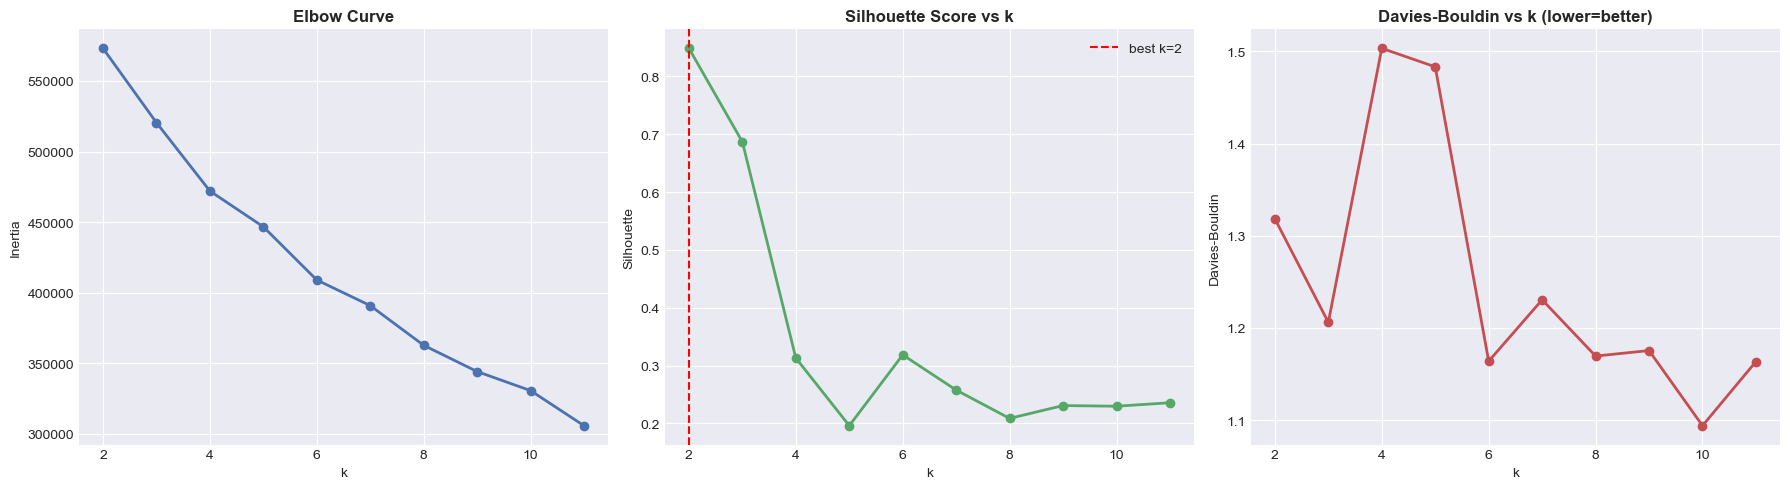

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, inertias, marker="o", color="#4C72B0", linewidth=2)
axes[0].set_title("Elbow Curve", fontweight="bold")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")

axes[1].plot(k_range, sil_km, marker="o", color="#55a868", linewidth=2)
axes[1].axvline(best_k, color="red", linestyle="--", label=f"best k={best_k}")
axes[1].set_title("Silhouette Score vs k", fontweight="bold")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette")
axes[1].legend()

axes[2].plot(k_range, db_km, marker="o", color="#c44e52", linewidth=2)
axes[2].set_title("Davies-Bouldin vs k (lower=better)", fontweight="bold")
axes[2].set_xlabel("k"); axes[2].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.show()

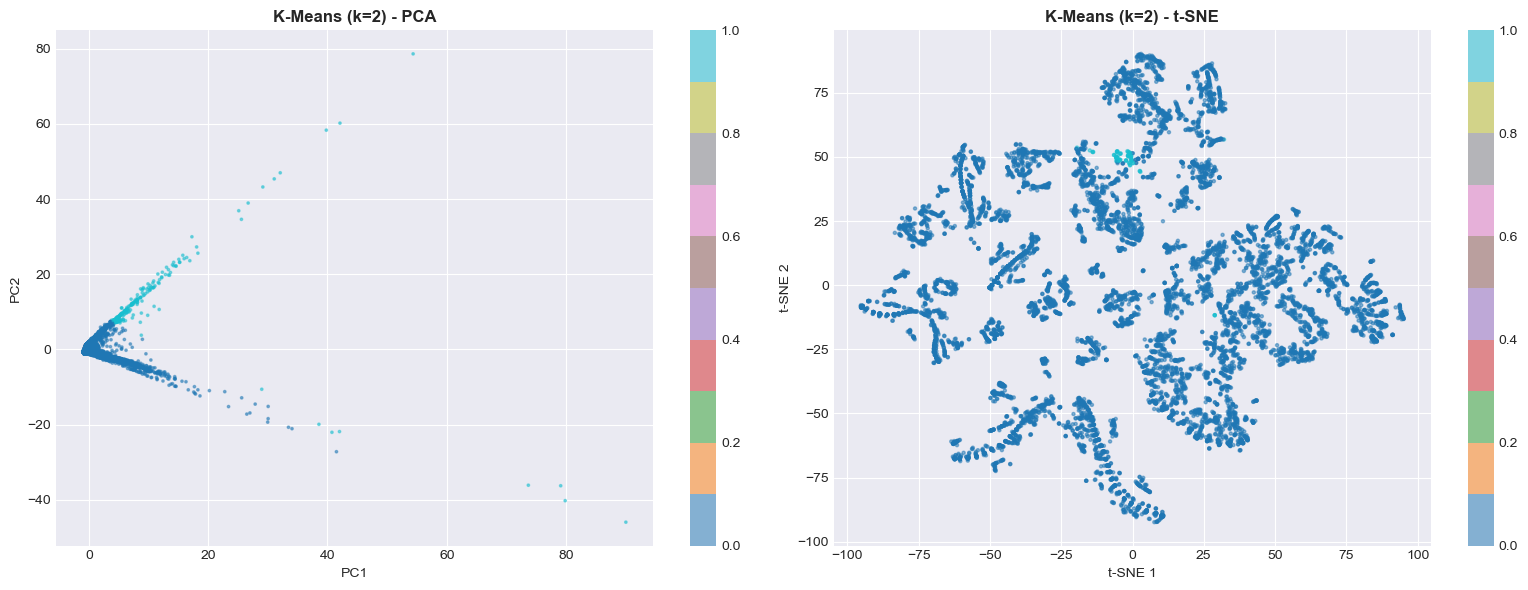

In [66]:
km_best = KMeans(n_clusters=best_k, n_init=20, random_state=42)
km_labels = km_best.fit_predict(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=km_labels, cmap=PALETTE, s=3, alpha=0.5)
axes[0].set_title(f"K-Means (k={best_k}) - PCA", fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=km_labels[idx], cmap=PALETTE, s=5, alpha=0.5)
axes[1].set_title(f"K-Means (k={best_k}) - t-SNE", fontweight="bold")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()

In [67]:
df2["KMeans_Cluster"] = km_labels
profile_cols = ["Active Oil Wells", "Active Gas Wells",
                "Oil Produced, bbl", "Gas Produced, Mcf",
                "Water produced, bbl", "Total_Wells"]
km_profile = df2.groupby("KMeans_Cluster")[profile_cols].mean()
print("K-Means Cluster Profiles (mean):")
print(km_profile.round(2).to_string())

K-Means Cluster Profiles (mean):
                Active Oil Wells  Active Gas Wells  Oil Produced, bbl  Gas Produced, Mcf  Water produced, bbl  Total_Wells
KMeans_Cluster                                                                                                            
0                           3.52              3.67             388.80           17372.03               729.39         9.53
1                         212.78             11.83           58720.52          119479.00            761979.19       360.00


## 6. Agglomerative Clustering

In [68]:
agg_results = {}
for k in [3, 4, 5, 6]:
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    lbl = agg.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, lbl, sample_size=5000, random_state=42)
    db  = davies_bouldin_score(X_scaled, lbl)
    ch  = calinski_harabasz_score(X_scaled, lbl)
    agg_results[k] = {"Silhouette": sil, "DB": db, "CH": ch, "labels": lbl}
    print(f"  k={k}  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.1f}")

best_agg_k = max(agg_results, key=lambda k: agg_results[k]["Silhouette"])
agg_labels = agg_results[best_agg_k]["labels"]
print(f"\nBest k by Silhouette: k={best_agg_k}")

  k=3  Sil=0.3288  DB=1.6267  CH=2839.6
  k=4  Sil=0.3028  DB=1.5470  CH=3037.1
  k=5  Sil=0.3054  DB=1.3160  CH=2933.4
  k=6  Sil=0.3054  DB=1.0969  CH=2891.8

Best k by Silhouette: k=3


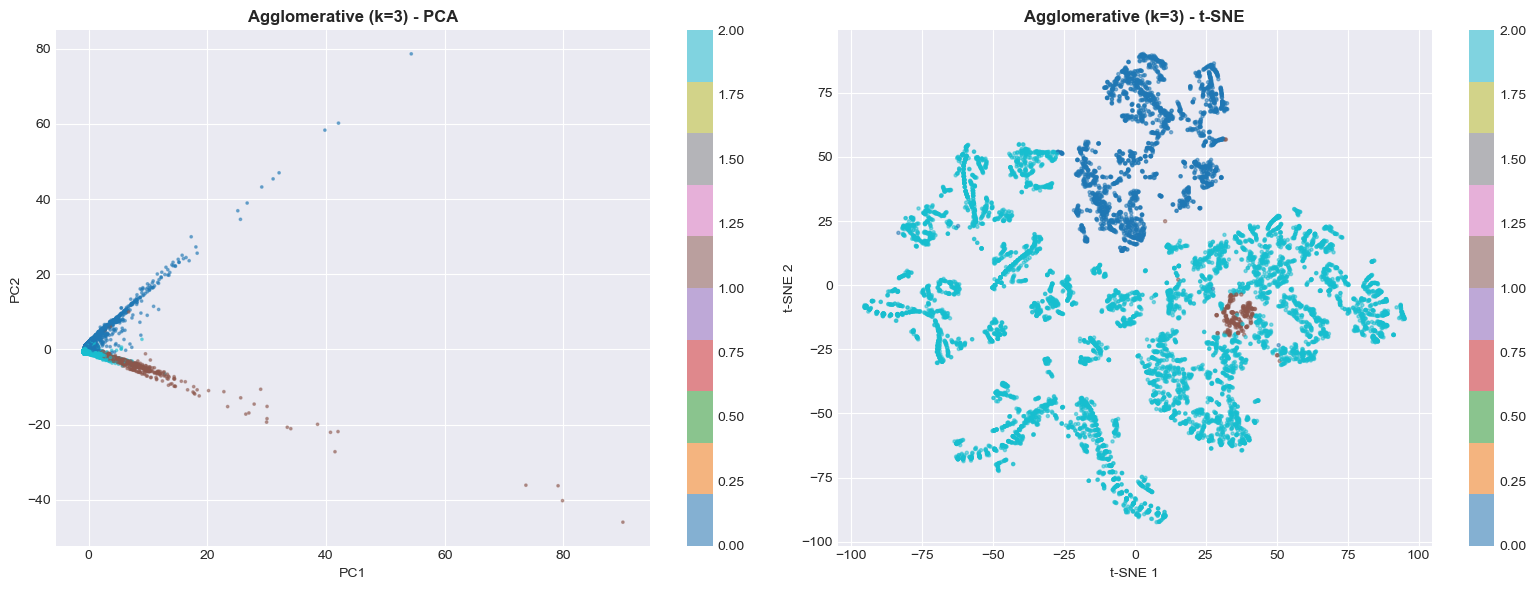

In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=agg_labels, cmap=PALETTE, s=3, alpha=0.5)
axes[0].set_title(f"Agglomerative (k={best_agg_k}) - PCA", fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg_labels[idx], cmap=PALETTE, s=5, alpha=0.5)
axes[1].set_title(f"Agglomerative (k={best_agg_k}) - t-SNE", fontweight="bold")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()

## 7. DBSCAN

In [70]:
dbscan_results = []
for eps in [0.5, 1.0, 1.5, 2.0]:
    for min_s in [5, 10, 20]:
        db = DBSCAN(eps=eps, min_samples=min_s, n_jobs=-1)
        lbl = db.fit_predict(X_scaled)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = (lbl == -1).sum()
        if n_clusters >= 2:
            sil = silhouette_score(X_scaled[lbl != -1], lbl[lbl != -1],
                                   sample_size=5000, random_state=42)
            dbscan_results.append({"eps": eps, "min_s": min_s,
                                   "n_clusters": n_clusters, "n_noise": n_noise,
                                   "Silhouette": sil, "labels": lbl})
            print(f"  eps={eps}, min_s={min_s}: {n_clusters} clusters, "
                  f"{n_noise} noise, Sil={sil:.4f}")
        else:
            print(f"  eps={eps}, min_s={min_s}: {n_clusters} cluster(s) - skip")

if dbscan_results:
    best_dbscan = max(dbscan_results, key=lambda r: r["Silhouette"])
    dbscan_labels = best_dbscan["labels"]
    print(f"\nBest DBSCAN: eps={best_dbscan['eps']}, min_s={best_dbscan['min_s']}, "
          f"Sil={best_dbscan['Silhouette']:.4f}")
else:
    best_dbscan = {"Silhouette": -1.0, "n_clusters": 0, "n_noise": len(X_scaled),
                   "eps": "N/A", "min_s": "N/A"}
    dbscan_labels = np.zeros(len(X_scaled), dtype=int)
    print("\nDBSCAN could not find valid clusters.")

  eps=0.5, min_s=5: 239 clusters, 4505 noise, Sil=-0.0227
  eps=0.5, min_s=10: 88 clusters, 6526 noise, Sil=0.0638
  eps=0.5, min_s=20: 59 clusters, 8630 noise, Sil=0.1663
  eps=1.0, min_s=5: 82 clusters, 1901 noise, Sil=-0.0236
  eps=1.0, min_s=10: 28 clusters, 2677 noise, Sil=-0.0052
  eps=1.0, min_s=20: 15 clusters, 3391 noise, Sil=0.0594
  eps=1.5, min_s=5: 44 clusters, 1009 noise, Sil=0.1318
  eps=1.5, min_s=10: 16 clusters, 1401 noise, Sil=0.1661
  eps=1.5, min_s=20: 6 clusters, 1898 noise, Sil=0.2447
  eps=2.0, min_s=5: 31 clusters, 677 noise, Sil=0.1980
  eps=2.0, min_s=10: 11 clusters, 967 noise, Sil=0.2123
  eps=2.0, min_s=20: 8 clusters, 1239 noise, Sil=0.2003

Best DBSCAN: eps=1.5, min_s=20, Sil=0.2447


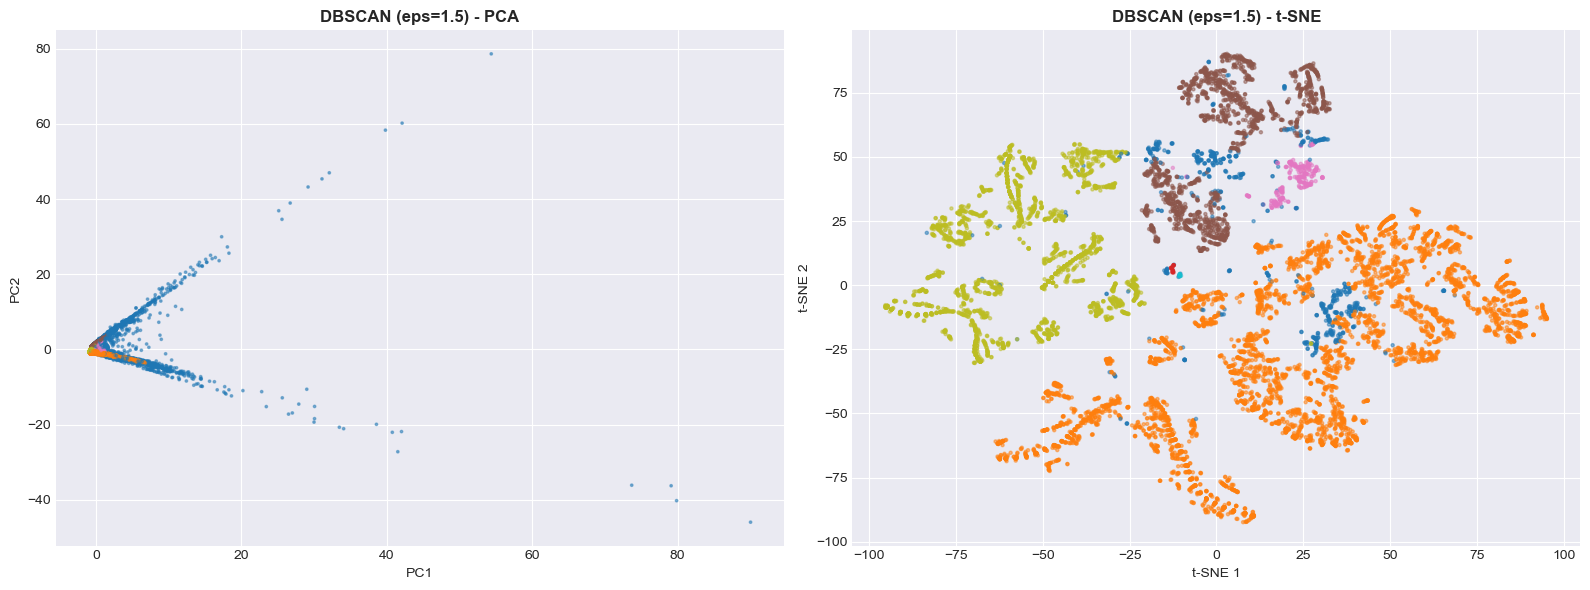

In [71]:
if dbscan_results:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = np.where(dbscan_labels == -1, -1, dbscan_labels)
    sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=colors, cmap=PALETTE, s=3, alpha=0.5)
    axes[0].set_title(f"DBSCAN (eps={best_dbscan['eps']}) - PCA", fontweight="bold")
    axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")

    sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors[idx], cmap=PALETTE, s=5, alpha=0.5)
    axes[1].set_title(f"DBSCAN (eps={best_dbscan['eps']}) - t-SNE", fontweight="bold")
    axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
    plt.tight_layout()
    plt.show()

## 8. Gaussian Mixture Model (GMM)

In [72]:
gmm_results = {}
for n in range(2, 9):
    gmm = GaussianMixture(n_components=n, covariance_type="full", n_init=3, random_state=42)
    gmm.fit(X_scaled)
    lbl = gmm.predict(X_scaled)
    sil = silhouette_score(X_scaled, lbl, sample_size=5000, random_state=42)
    db  = davies_bouldin_score(X_scaled, lbl)
    ch  = calinski_harabasz_score(X_scaled, lbl)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    gmm_results[n] = {"Silhouette": sil, "DB": db, "CH": ch, "BIC": bic, "AIC": aic, "labels": lbl}
    print(f"  n={n}  Sil={sil:.4f}  DB={db:.4f}  CH={ch:.1f}  BIC={bic:.0f}  AIC={aic:.0f}")

best_gmm_n = min(gmm_results, key=lambda n: gmm_results[n]["BIC"])
print(f"\nBest n by BIC: n={best_gmm_n}")

  n=2  Sil=0.2766  DB=2.0870  CH=2594.0  BIC=-1835423  AIC=-1839620
  n=3  Sil=0.0939  DB=3.2615  CH=1127.8  BIC=-2439339  AIC=-2445639
  n=4  Sil=0.1163  DB=3.4272  CH=1291.8  BIC=-3003531  AIC=-3011933
  n=5  Sil=0.2090  DB=2.3161  CH=1704.1  BIC=-3471446  AIC=-3481951
  n=6  Sil=0.1068  DB=2.4498  CH=1426.4  BIC=-3580681  AIC=-3593289
  n=7  Sil=0.2083  DB=1.8807  CH=1764.8  BIC=-3453608  AIC=-3468318
  n=8  Sil=0.1982  DB=2.3633  CH=1454.1  BIC=-3616473  AIC=-3633285

Best n by BIC: n=8


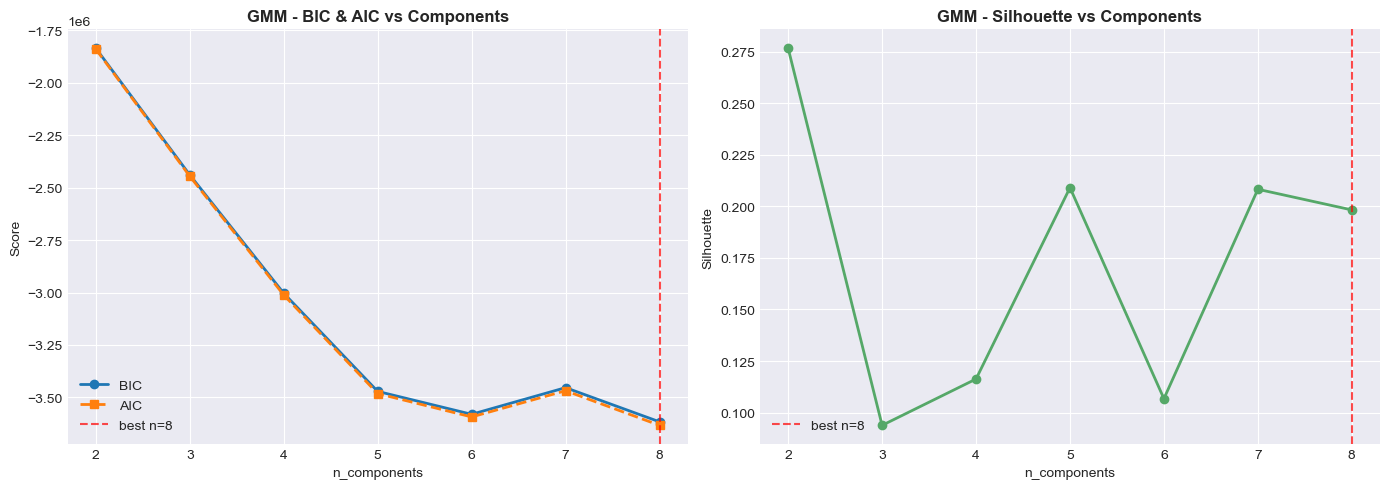

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ns = list(gmm_results.keys())

axes[0].plot(ns, [gmm_results[n]["BIC"] for n in ns], marker="o", label="BIC", linewidth=2)
axes[0].plot(ns, [gmm_results[n]["AIC"] for n in ns], marker="s", label="AIC", linewidth=2, linestyle="--")
axes[0].axvline(best_gmm_n, color="red", linestyle="--", alpha=0.7, label=f"best n={best_gmm_n}")
axes[0].set_title("GMM - BIC & AIC vs Components", fontweight="bold")
axes[0].set_xlabel("n_components"); axes[0].set_ylabel("Score")
axes[0].legend()

axes[1].plot(ns, [gmm_results[n]["Silhouette"] for n in ns], marker="o", color="#55a868", linewidth=2)
axes[1].axvline(best_gmm_n, color="red", linestyle="--", alpha=0.7, label=f"best n={best_gmm_n}")
axes[1].set_title("GMM - Silhouette vs Components", fontweight="bold")
axes[1].set_xlabel("n_components"); axes[1].set_ylabel("Silhouette")
axes[1].legend()

plt.tight_layout()
plt.show()

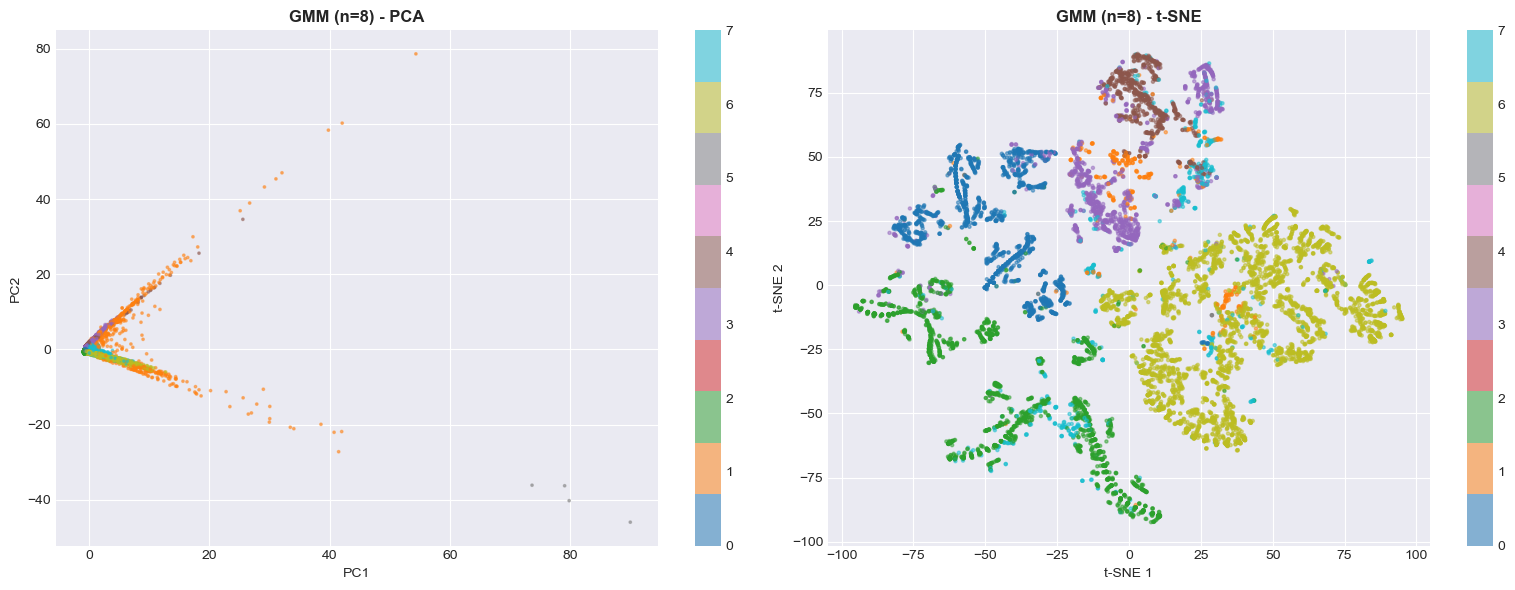

In [74]:
gmm_labels = gmm_results[best_gmm_n]["labels"]
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=gmm_labels, cmap=PALETTE, s=3, alpha=0.5)
axes[0].set_title(f"GMM (n={best_gmm_n}) - PCA", fontweight="bold")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
plt.colorbar(sc, ax=axes[0])

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=gmm_labels[idx], cmap=PALETTE, s=5, alpha=0.5)
axes[1].set_title(f"GMM (n={best_gmm_n}) - t-SNE", fontweight="bold")
axes[1].set_xlabel("t-SNE 1"); axes[1].set_ylabel("t-SNE 2")
plt.colorbar(sc2, ax=axes[1])
plt.tight_layout()
plt.show()

## 9. Algorithm Comparison

In [75]:
def get_metrics(X, labels):
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {"Silhouette": float("nan"), "Davies-Bouldin": float("nan"), "Calinski-Harabasz": float("nan")}
    sil = silhouette_score(X[mask], labels[mask], sample_size=5000, random_state=42)
    db  = davies_bouldin_score(X[mask], labels[mask])
    ch  = calinski_harabasz_score(X[mask], labels[mask])
    return {"Silhouette": round(sil, 4), "Davies-Bouldin": round(db, 4), "Calinski-Harabasz": round(ch, 1)}

summary = {}
summary[f"KMeans (k={best_k})"]        = get_metrics(X_scaled, km_labels)
summary[f"Agglom (k={best_agg_k})"]    = get_metrics(X_scaled, agg_labels)
if dbscan_results:
    summary[f"DBSCAN (eps={best_dbscan['eps']})"] = get_metrics(X_scaled, dbscan_labels)
summary[f"GMM (n={best_gmm_n})"]        = get_metrics(X_scaled, gmm_labels)

results_df = pd.DataFrame(summary).T
print("=" * 70)
print("  ALGORITHM COMPARISON SUMMARY")
print("=" * 70)
print(results_df.to_string())
print("=" * 70)

  ALGORITHM COMPARISON SUMMARY
                  Silhouette  Davies-Bouldin  Calinski-Harabasz
KMeans (k=2)          0.8484          1.3183             3042.6
Agglom (k=3)          0.3288          1.6267             2839.6
DBSCAN (eps=1.5)      0.2447          1.6482             2899.1
GMM (n=8)             0.1982          2.3633             1454.1


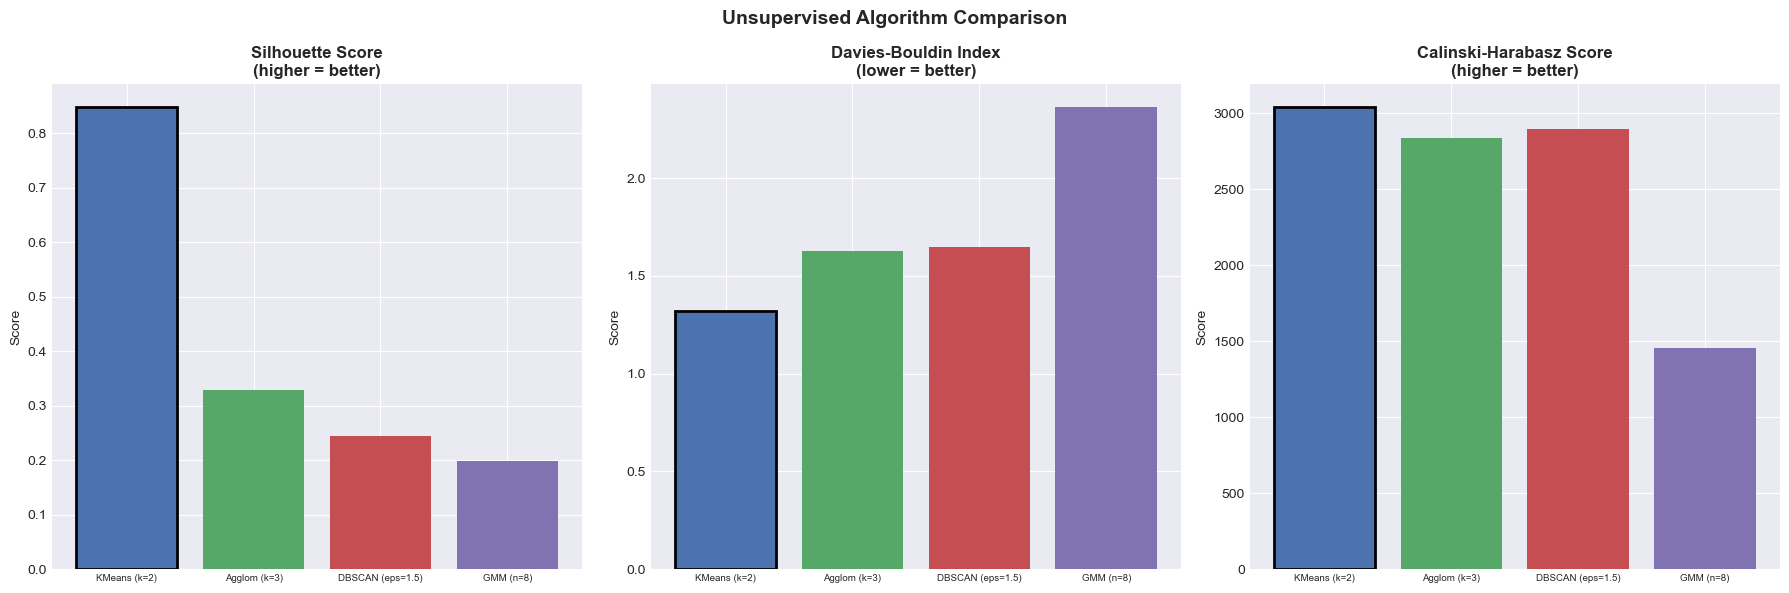

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors_bar = ["#4C72B0", "#55a868", "#c44e52", "#8172b2"]
alg_names = results_df.index.tolist()

for i, (metric, title, better) in enumerate([
    ("Silhouette", "Silhouette Score\n(higher = better)", "max"),
    ("Davies-Bouldin", "Davies-Bouldin Index\n(lower = better)", "min"),
    ("Calinski-Harabasz", "Calinski-Harabasz Score\n(higher = better)", "max"),
]):
    vals = results_df[metric]
    bars = axes[i].bar(alg_names, vals, color=colors_bar[:len(results_df)])
    best_idx = vals.idxmax() if better == "max" else vals.idxmin()
    best_pos = list(results_df.index).index(best_idx)
    bars[best_pos].set_edgecolor("black")
    bars[best_pos].set_linewidth(2)
    axes[i].set_title(title, fontweight="bold")
    axes[i].set_ylabel("Score")
    axes[i].tick_params(axis="x", labelsize=7)

fig.suptitle("Unsupervised Algorithm Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. Cluster Profile Heatmap

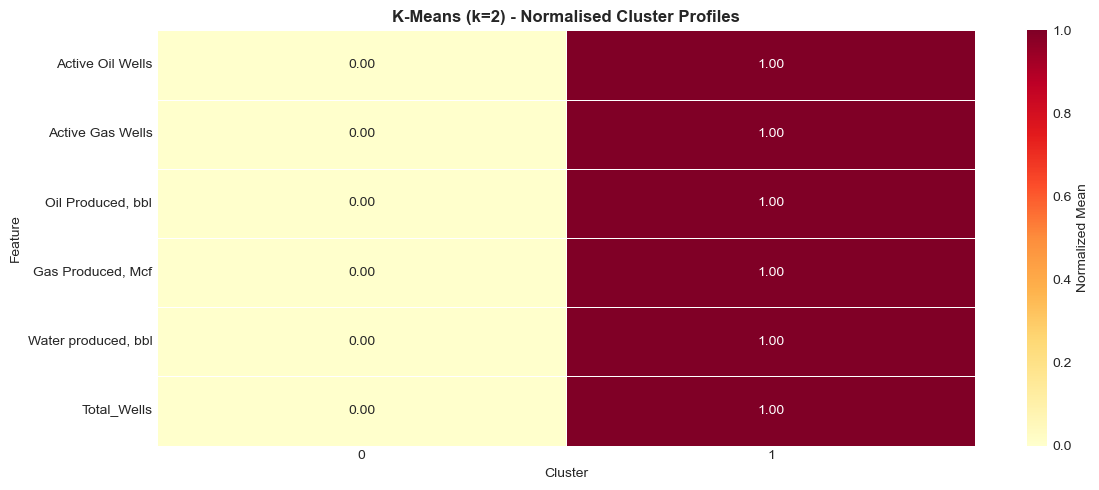

In [77]:
profile = df2.groupby("KMeans_Cluster")[profile_cols].mean()
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_norm.T, annot=True, fmt=".2f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "Normalized Mean"})
ax.set_title(f"K-Means (k={best_k}) - Normalised Cluster Profiles", fontweight="bold")
ax.set_xlabel("Cluster"); ax.set_ylabel("Feature")
plt.tight_layout()
plt.show()

## 11. Final Verdict

In [78]:
best_overall = results_df["Silhouette"].idxmax()

print("=" * 70)
print("  FINAL VERDICT")
print("=" * 70)
print(f"\n  Best Algorithm: {best_overall}")
print(f"  Silhouette:        {results_df.loc[best_overall, 'Silhouette']:.4f} (BEST)")
print(f"  Davies-Bouldin:    {results_df.loc[best_overall, 'Davies-Bouldin']:.4f}")
print(f"  Calinski-Harabasz: {results_df.loc[best_overall, 'Calinski-Harabasz']:.1f}")
print("\n  Full results:")
print(results_df.to_string())
print("=" * 70)

  FINAL VERDICT

  Best Algorithm: KMeans (k=2)
  Silhouette:        0.8484 (BEST)
  Davies-Bouldin:    1.3183
  Calinski-Harabasz: 3042.6

  Full results:
                  Silhouette  Davies-Bouldin  Calinski-Harabasz
KMeans (k=2)          0.8484          1.3183             3042.6
Agglom (k=3)          0.3288          1.6267             2839.6
DBSCAN (eps=1.5)      0.2447          1.6482             2899.1
GMM (n=8)             0.1982          2.3633             1454.1
